# Time-of-Day Clustering - Normalised Profile Analysis

**Dataset:** `data/clean/final_dataset_full_clean.csv`

**Problem with the previous approach:** Clustering on raw hourly price features caused one cluster to be dominated by high absolute prices (particularly the 2022 energy crisis), losing any connection to time-of-day structure.

**This approach:** Each day is represented as a 24-hour price vector. Before clustering, we apply per-day Min-Max normalisation - rescaling each day's prices to the [0, 1] range.

## 1. Load Data and Build Daily Price Profiles

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

df = pd.read_csv('../data/clean/final_dataset_full_clean.csv', parse_dates=['time'])
df['date'] = df['time'].dt.date
df['hour'] = df['time'].dt.hour

# Pivot: rows = days, columns = hours 0–23, values = price
pivot_df = df.pivot(index='date', columns='hour', values='price').dropna()

print(f'Daily price profile matrix: {pivot_df.shape[0]} days × {pivot_df.shape[1]} hours')
print(f'Date range: {pivot_df.index.min()} -> {pivot_df.index.max()}')

Daily price profile matrix: 3991 days × 24 hours
Date range: 2015-01-05 → 2025-12-31


## 2. Per-Day Normalisation

Standard scaling across the whole dataset would still let price level influence the result - a day where all hours are expensive would sit far from a cheap day even if their shapes are identical. Instead we apply Min-Max scaling row-by-row: each day's prices are independently rescaled so the cheapest hour of that day = 0 and the most expensive = 1.

After this step, the only information left is *when* within the day prices are high relative to the same day's trough — the absolute level is gone.

In [2]:
scaler = MinMaxScaler()

# fit_transform works column-wise by default, so we transpose, scale, then transpose back
# Result: each row (day) is independently scaled to [0, 1]
pivot_norm = pd.DataFrame(
    scaler.fit_transform(pivot_df.T).T,
    index=pivot_df.index,
    columns=pivot_df.columns,
)

print(f'Per-day normalised matrix: {pivot_norm.shape}')
print(f'Row min (should all be 0): {pivot_norm.min(axis=1).describe().round(3).to_dict()}')
print(f'Row max (should all be 1): {pivot_norm.max(axis=1).describe().round(3).to_dict()}')

Per-day normalised matrix: (3991, 24)
Row min (should all be 0): {'count': 3991.0, 'mean': 0.0, 'std': 0.0, 'min': 0.0, '25%': 0.0, '50%': 0.0, '75%': 0.0, 'max': 0.0}
Row max (should all be 1): {'count': 3991.0, 'mean': 1.0, 'std': 0.0, 'min': 1.0, '25%': 1.0, '50%': 1.0, '75%': 1.0, 'max': 1.0}


## 3. Fit K-Means (k = 4)

K-means is applied to the normalised shapes. The model never sees the original price values — only the within-day relative timing.

In [3]:
K = 4
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
pivot_df['cluster'] = kmeans.fit_predict(pivot_norm)

counts = pivot_df['cluster'].value_counts().sort_index()
print('Days per cluster:')
for c, n in counts.items():
    print(f'  Cluster {c}: {n:>4} days  ({n / len(pivot_df) * 100:.1f}%)')

Days per cluster:
  Cluster 0: 1418 days  (35.5%)
  Cluster 1:  919 days  (23.0%)
  Cluster 2:  964 days  (24.2%)
  Cluster 3:  690 days  (17.3%)


## 4. Visualise the Cluster Shapes

Two panels side by side:
- Left - what the algorithm saw: the mean normalised shape for each cluster. This is the actual basis for the groupings.
- Right - real-world prices: the mean *actual* price profile for each cluster. This shows whether the shape groups correspond to recognisably different price levels, even though level played no role in forming them.

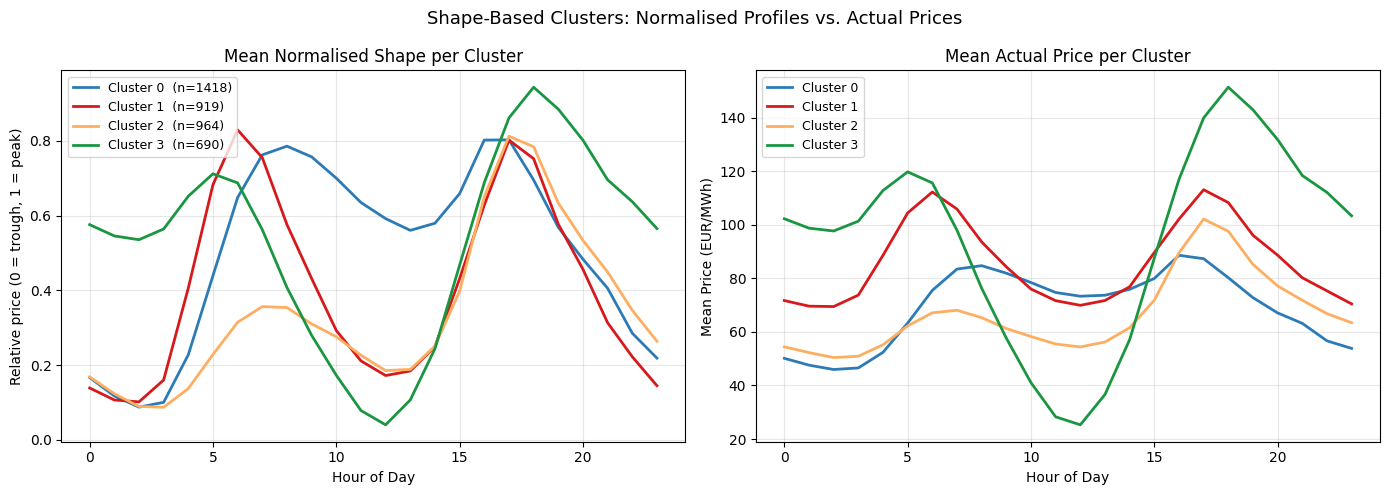

In [4]:
COLORS = ['#2c7bb6', '#d7191c', '#fdae61', '#1a9641']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: normalised shapes (what the algorithm used)
for c in range(K):
    mask  = pivot_df['cluster'] == c
    shape = pivot_norm[mask].mean()
    n     = mask.sum()
    axes[0].plot(shape, color=COLORS[c], lw=2, label=f'Cluster {c}  (n={n})')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Relative price (0 = trough, 1 = peak)')
axes[0].set_title('Mean Normalised Shape per Cluster')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Right: actual price levels
for c in range(K):
    mask   = pivot_df['cluster'] == c
    actual = pivot_df[mask].drop(columns='cluster').mean()
    axes[1].plot(actual, color=COLORS[c], lw=2, label=f'Cluster {c}')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Mean Price (EUR/MWh)')
axes[1].set_title('Mean Actual Price per Cluster')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

fig.suptitle('Shape-Based Clusters: Normalised Profiles vs. Actual Prices', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Interpretation

**What the left plot shows (normalised shapes)**
The normalised shapes reveal how intraday price timing differs across clusters, independent of price level. Look at where each curve peaks and where it troughs - a midday dip in one cluster, a sharp evening ramp in another, a flat curve in a third. These structural differences are what the algorithm used to form the groups.

**What the right plot shows (actual prices)**
Even though price level was excluded from clustering, the actual price plot shows that different shape clusters still end up at different price levels. This is expected: the timing of peaks is itself driven by supply-demand dynamics, which correlate with the overall price environment. A cluster with a pronounced solar midday dip is, by definition, a cluster of high-solar days — which tend to be lower-priced.

**Why this is more useful than the original approach**
In the previous version, one cluster was essentially a 2022 crisis cluster - it grouped expensive days together regardless of when within the day those prices occurred. That cluster told us about price magnitude, not market structure. By normalising first, we separate the two questions: *ggghow expensive was this day?* (answered by the right plot) and *what was the timing pattern?* (answered by the left plot). The left plot is the one relevant to forecasting daily shape.

**What to look for in the cluster sizes**
Very small clusters usually represent outlier shapes - days where the intraday pattern is unusual enough that the algorithm cannot absorb them into the main groups. These are worth inspecting individually to understand what market conditions drove them.